---
<a id="top"></a>
# Tutorial: FALP and Self-Guided ALP for Inventory Control
---
This notebook is a compact, end-to-end tutorial on approximate linear programming for a single-product inventory Markov decision process. It is written to be approachable for readers who want both the computational workflow and the modeling logic.

**Learning goals**
- understand what is being approximated in FALP and in self-guided ALP
- see how the random-feature basis enters the value-function approximation
- compare lower bounds, upper bounds, and optimality gaps as model size grows
- visualize how guiding constraints change the fitted value functions and state-relevance weights

**Project and authors**
- Co-authors: [Andre Cire](https://utsc.utoronto.ca/mgmt/andre-cire), [Selva Nadarajah](https://selvan.people.uic.edu/), [Parshan Pakiman](https://parshanpakiman.github.io/), [Negar Soheili](https://www.negar-soheili.com/)
- GitHub: [self-adapting-mdp-approximations/informs-tutorials](https://github.com/self-adapting-mdp-approximations/informs-tutorials)



---
<a id="toc"></a>
## Table of Contents

1. [Setup](#setup)
2. [Imports and Shared Style](#imports)
3. [Problem Map and Notation](#notation)
4. [FALP Experiments](#falp)
5. [FALP Plots](#falp-plots)
6. [Self-Guided ALP Experiments](#sgalp)
7. [Self-Guided ALP Plots](#sgalp-plots)
8. [Understanding the Guiding Mechanism](#guiding)
9. [FALP vs SGALP Policy Costs](#policy-costs)


---
<a id="setup"></a>
## 1. Setup

Run the next cell once if you want the notebook to create a lightweight local environment. If you already have the dependencies installed, you can skip it.


In [1]:
%%bash

if python3 - <<'PY_DEPENDENCIES'
import importlib.util
required = ["numpy", "scipy", "matplotlib", "emcee"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
raise SystemExit(1 if missing else 0)
PY_DEPENDENCIES
then
    echo "Core tutorial dependencies already available; skipping environment setup."
    exit 0
fi

echo "Building a Python environment ..."
python3 -m venv ../.venv >/dev/null 2>&1
source ../.venv/bin/activate
python -m pip install --upgrade pip >/dev/null 2>&1
python -m pip install numpy scipy matplotlib emcee jupyter ipykernel >/dev/null 2>&1
echo "All done."


Building a Python environment ...
All done.


<a id="imports"></a>
## 2. Imports and Shared Style

The notebooks now live in `Notebooks/`, so the next cell first adds the parent project folder to Python's import path. After that, we import the shared modules from the main folder and the ALP-specific classes/configs from `Self_Guided_ALP/`.


In [2]:
import sys
from pathlib import Path


def find_project_root(start_path: Path) -> Path:
    """
    Find the tutorial project root by looking for the shared Python modules.

    Args:
        start_path: Directory from which to begin the upward search.
    """
    for candidate in (start_path, *start_path.parents):
        if (candidate / "helper.py").exists() and (candidate / "config.py").exists():
            return candidate
    raise RuntimeError("Could not locate the tutorial project root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from helper import (
    apply_tutorial_plot_style,
    make_shared_evaluation_configs,
    run_falp_grid,
    run_sgalp_grid,
    run_falp_and_sgalp_comparison,
    plot_value_function_curves,
    plot_bound_boxplots,
    plot_falp_vs_sgalp_vfas_and_relevance,
    plot_falp_vs_sgalp_policy_costs,
    summarize_falp_vs_sgalp_policy_costs,
)
from Self_Guided_ALP.sgalp import SelfGuidedALP
from config import FALPConfig, SGALPConfig, RandomFeatureConfig, GuidingConstraintConfig

apply_tutorial_plot_style()

shared_lower_bound_config, shared_policy_config = make_shared_evaluation_configs(initial_state=0.0)


<a id="notation"></a>
## 3. Problem Map and Notation

| Object | Meaning | Where it appears |
| --- | --- | --- |
| `s` | current inventory state | horizontal axis in the value-function plots |
| `a` | order quantity | chosen by the policy |
| `\hat V(s)` | approximate value function | fitted by FALP or SGALP |
| `m` | number of random Fourier features | controls approximation richness |
| lower bound | sampling-based performance certificate | should go up as the approximation improves |
| upper bound | simulated greedy-policy cost | should go down as the policy improves |
| optimality gap | relative distance between upper and lower bounds | smaller is better |

The inventory instance is the same throughout the notebook. What changes is the approximation architecture and the way constraints are enforced.


---
<a id="falp"></a>
## 4. FALP Experiments

We first solve the fitted approximate linear program (FALP) for a sequence of feature counts. The code below separates the experiment into three parameter bundles:
- `falp_config` controls the basis family and LP sampling sizes
- `falp_lower_bound_config` controls the stochastic lower-bound estimator
- `falp_policy_config` controls greedy-policy simulation for the upper bound

This makes the design choices explicit and avoids long constructor calls.


In [3]:
# This is the expensive FALP cell. Run it once and reuse the cached results below.
falp_feature_counts = [0, 1, 2, 3, 4]
falp_seed_grid = [111, 222, 333, 444, 555]
num_constraints = 500

falp_config = FALPConfig(
    num_random_features=0,  # placeholder; falp_feature_counts updates this for each m
    num_constraints=num_constraints,
    num_state_relevance_samples=num_constraints,
    random_features=RandomFeatureConfig(
        bandwidth_choices=(1e-2, 1e-5),
        random_seed=111, # placeholder; run_falp_grid updates this for each seed
    ),
)

falp_results = run_falp_grid(
    feature_counts=falp_feature_counts,
    seeds=falp_seed_grid,
    falp_config=falp_config,
    lower_bound_config=shared_lower_bound_config,
    policy_config=shared_policy_config,
    compute_upper_bound=True,
)


    seed   # features         FALP obj    CVL lower bound      policy cost    opt gap %   time (sec)
--------------------------------------------------------------------------------------------------------
     111            0            118.1              113.9           3523.9         96.8         9.64
     111            1           1981.9             1968.1           2455.0         19.8        10.82
     111            2           2157.8             2138.0           2147.8          0.5        11.57
     111            3           2163.5             2137.9           2147.9          0.5        12.18
     111            4           2165.7             2136.8           2148.0          0.5        12.91
--------------------------------------------------------------------------------------------------------
     222            0            118.1              113.9           3480.7         96.7         9.51
     222            1           2021.2             1998.1           2174.0         

---
<a id="falp-plots"></a>
## 5. FALP Plots

The first figure shows two complementary views:
- left: the fitted value functions on a log scale, which makes shape differences easier to see
- right: the mean FALP objective value as the basis gets richer

For the curves we use one representative seed so that the geometry of the fitted functions is easy to inspect.


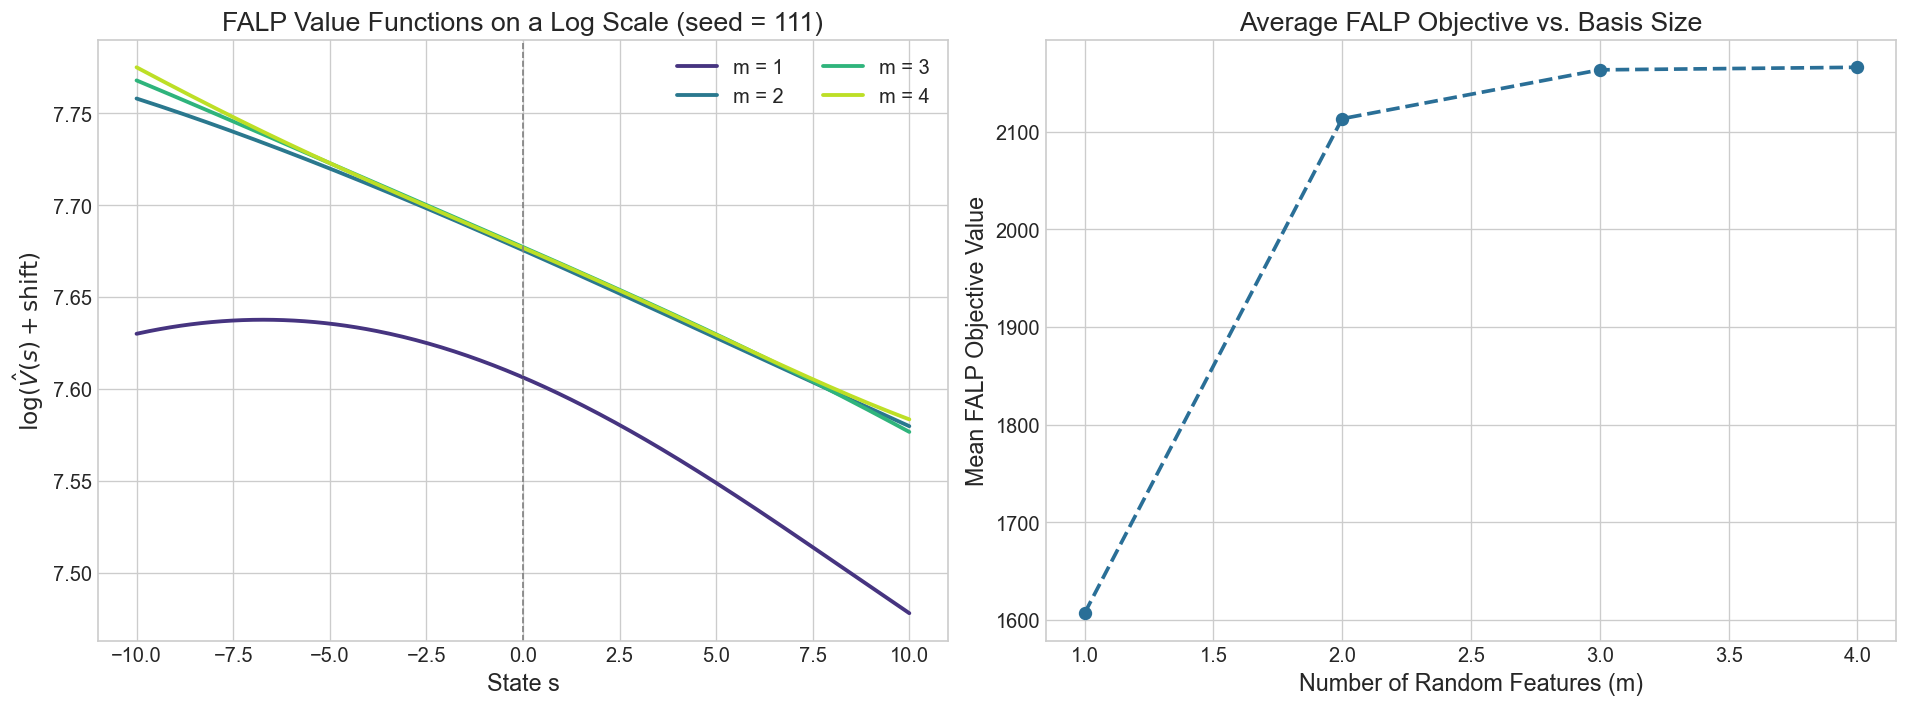

In [4]:
curve_feature_counts = [1, 2, 3, 4]
plot_value_function_curves(
    falp_results,
    curve_feature_counts,
    falp_seed_grid,
    algorithm_name="FALP",
    grid_size=300,
    colormap="viridis",
    objective_color="#2a6f97",
)


The next figure summarizes performance across random seeds. When you read it, the ideal pattern is:
- lower bounds rise,
- upper bounds fall,
- the gap between them shrinks.


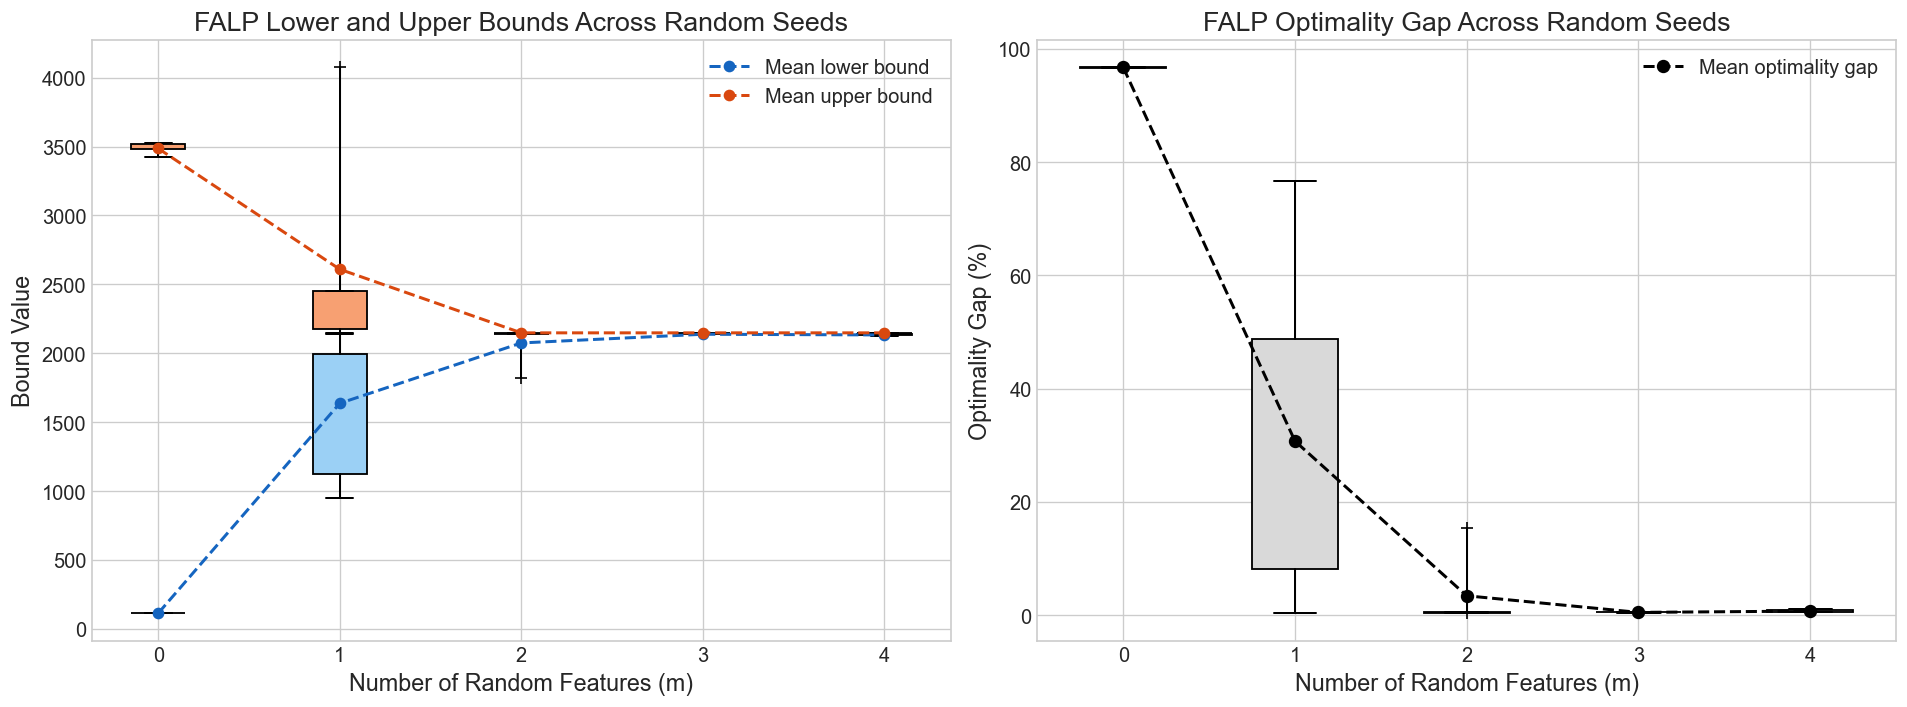

In [5]:
plot_bound_boxplots(
    falp_results,
    falp_feature_counts,
    falp_seed_grid,
    algorithm_name="FALP",
)


---
<a id="sgalp"></a>
## 6. Self-Guided ALP Experiments

Self-guided ALP reuses the same basic ingredients, but it solves a sequence of models and adds guiding constraints so the new approximation does not drift too far below the previous one on sampled states.

In the config below, the `guiding` block isolates the parameters that are specific to SGALP. That makes it easier to explain what is algorithm-specific versus what is shared with plain FALP.


In [6]:
# This is the expensive SGALP cell. Run it once and reuse the cached results below.
sgalp_feature_counts = [0, 1, 2, 3, 4]
sgalp_seed_grid = [111, 222, 333, 444, 555]
num_constraints = 500

sgalp_config = SGALPConfig(
    max_random_features=0,  # placeholder; run_sgalp_grid updates this for each m
    batch_size=1,
    num_constraints=num_constraints,
    num_state_relevance_samples=num_constraints,
    random_features=RandomFeatureConfig(
        bandwidth_choices=(1e-2, 1e-5),
        random_seed=111,
    ),
    guiding=GuidingConstraintConfig(
        num_guiding_states=num_constraints,
        allowed_violation=0.0,
        relax_fraction=0.02,
        absolute_floor=1e-6,
        retry_scales=(1.0, 2.0, 5.0, 10.0),
    ),
)

sgalp_results = run_sgalp_grid(
    feature_counts=sgalp_feature_counts,
    sgalp_class=SelfGuidedALP,
    seeds=sgalp_seed_grid,
    sgalp_config=sgalp_config,
    lower_bound_config=shared_lower_bound_config,
    policy_config=shared_policy_config,
    compute_upper_bound=True,
)


    seed   # features        SGALP obj    CVL lower bound      policy cost    opt gap %   time (sec)
--------------------------------------------------------------------------------------------------------
     111            0            118.1              113.9           3523.9         96.8         9.52
     111            1           1981.9             1968.1           2455.0         19.8        10.95
     111            2           2157.8             2138.0           2147.8          0.5        11.46
     111            3           2163.5             2137.9           2147.9          0.5        12.18
     111            4           2165.7             2136.8           2148.0          0.5        13.16
--------------------------------------------------------------------------------------------------------
     222            0            118.1              113.9           3480.7         96.7         9.66
     222            1           2021.2             1998.1           2174.0         

---
<a id="sgalp-plots"></a>
## 7. Self-Guided ALP Plots

We now look at the same diagnostics for SGALP. This makes the comparison with FALP apples-to-apples: same inventory instance, same feature counts, and similar plotting conventions.


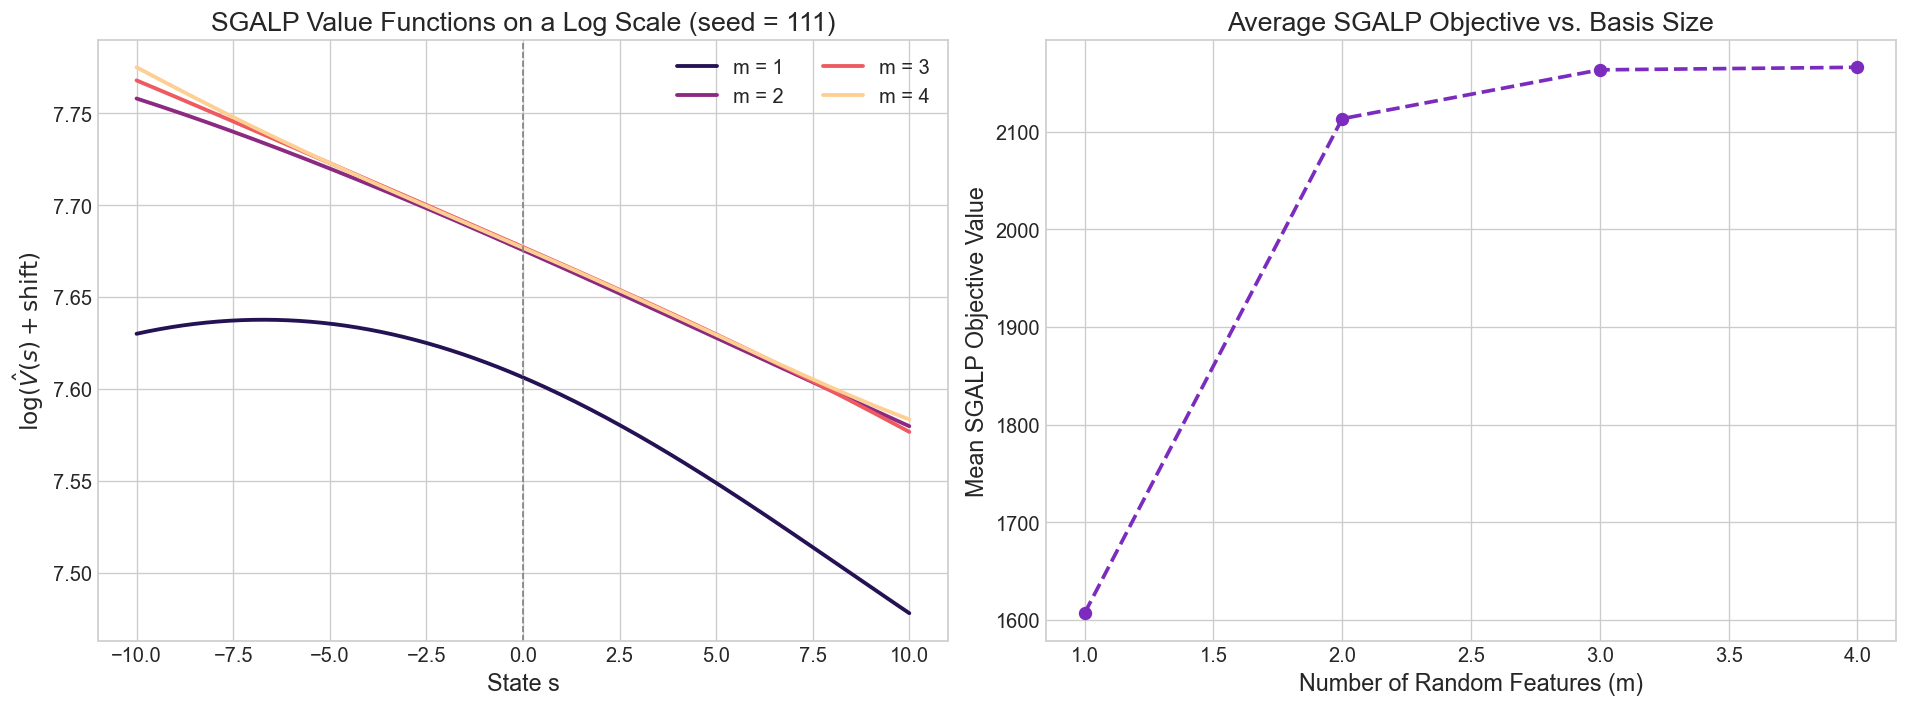

In [7]:
curve_feature_counts = [1, 2, 3, 4]
plot_value_function_curves(
    sgalp_results,
    curve_feature_counts,
    sgalp_seed_grid,
    algorithm_name="SGALP",
    grid_size=200,
    colormap="magma",
    objective_color="#7b2cbf",
)


The next figure asks the same question as before: does increasing model richness tighten the interval between the lower and upper bounds? This is the simplest empirical way to compare FALP and SGALP in the tutorial setting.


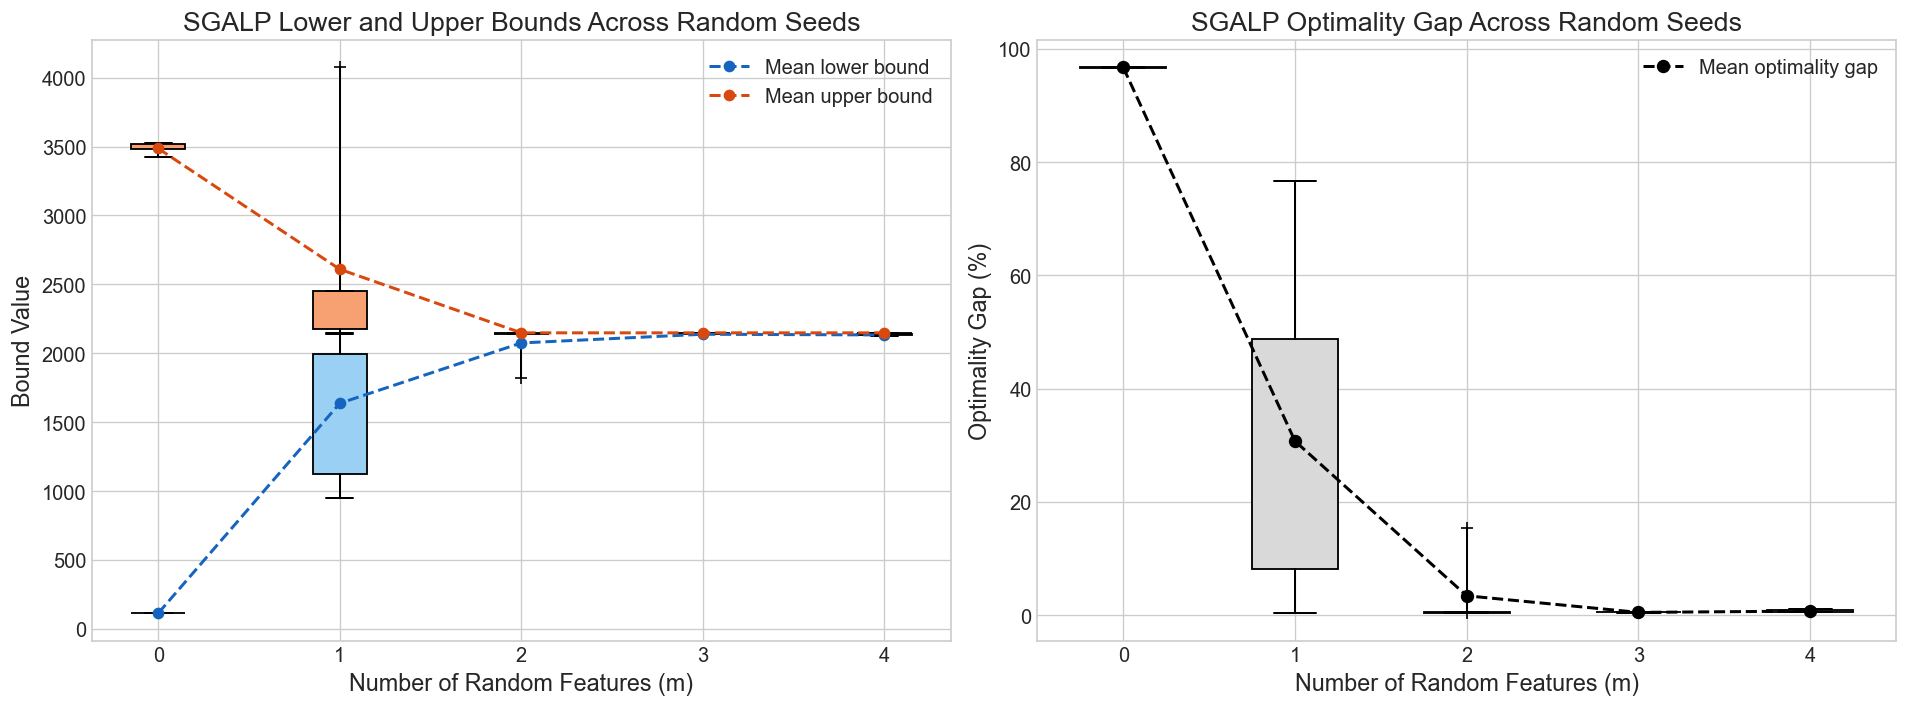

In [8]:
plot_bound_boxplots(
    sgalp_results,
    sgalp_feature_counts,
    sgalp_seed_grid,
    algorithm_name="SGALP",
)


---
<a id="guiding"></a>
## 8. Understanding the Guiding Mechanism

This figure is the most diagnostic one in the notebook.

It compares FALP and SGALP stage by stage and also visualizes the updated state-relevance density induced by the guiding constraints. This is useful because the self-guiding mechanism is not only changing the final objective value; it is also changing which regions of the state space receive extra attention.


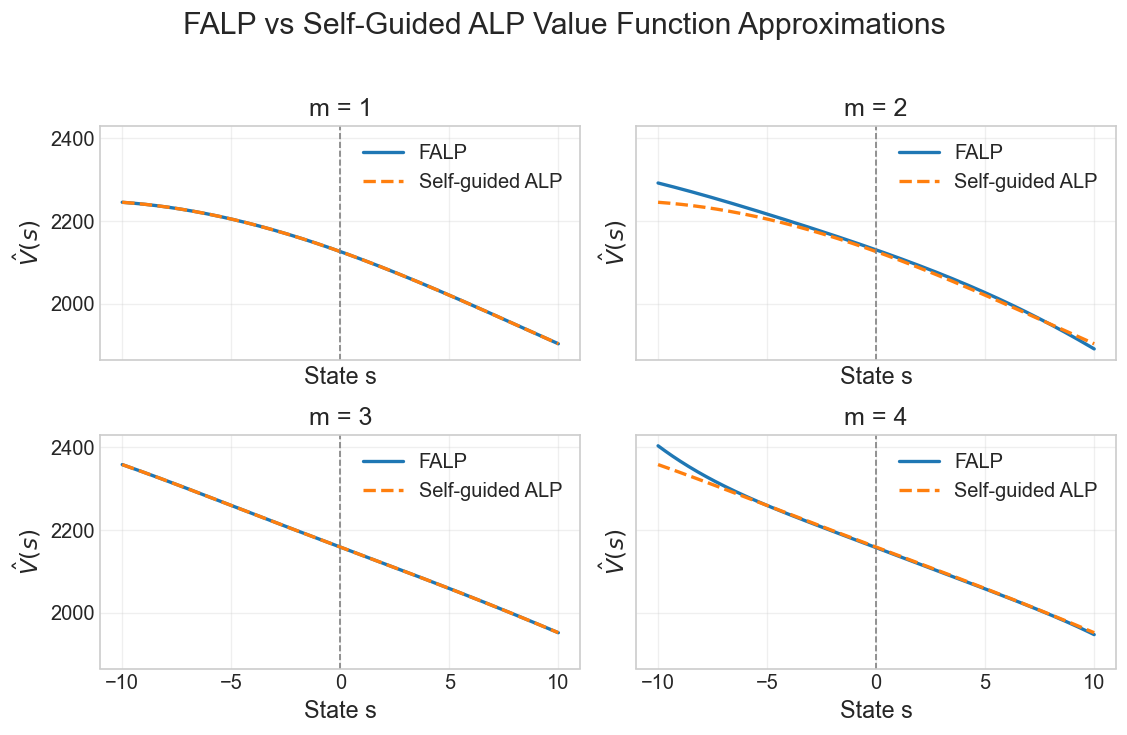

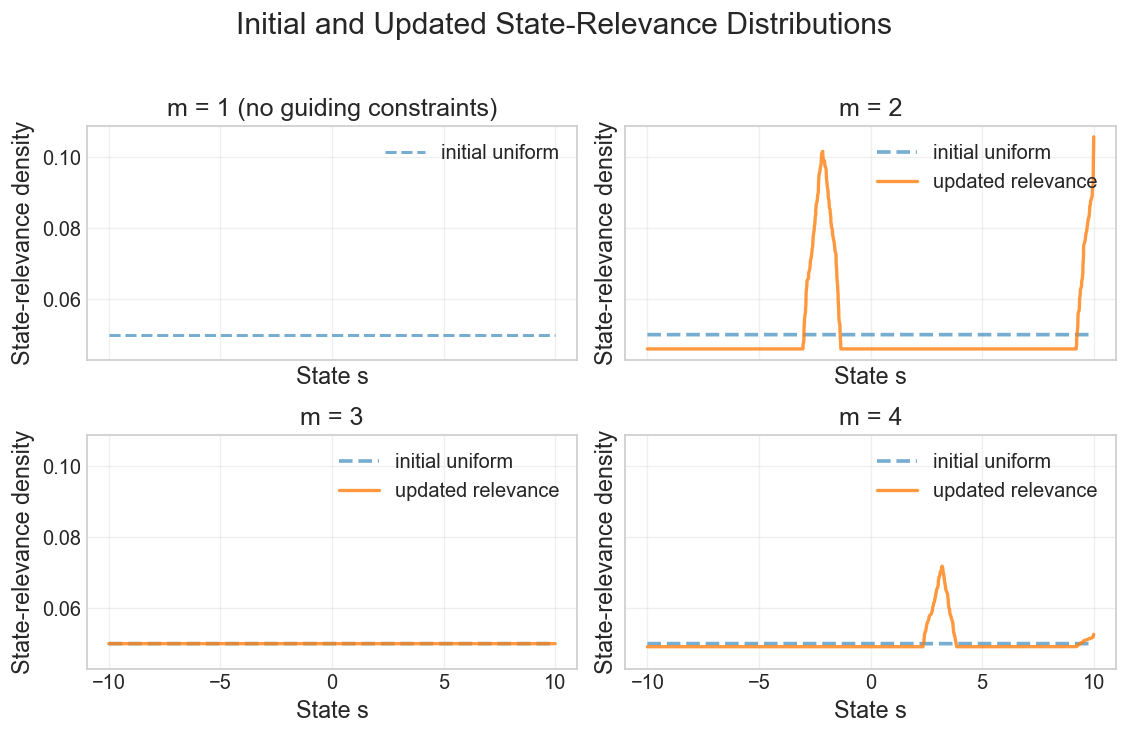

In [9]:
comparison_results = run_falp_and_sgalp_comparison(
    sgalp_class=SelfGuidedALP,
    max_random_features=4,
    num_constraints=500,
    num_state_relevance_samples=500,
    num_guiding_states=2000,
    bandwidth_choices=(1e-1, 1e-2),
    basis_seed=777,
    guiding_violation=0.0,
    guiding_relax_fraction=0.0,
    guiding_abs_floor=1e-7,
    guiding_retry_scales=(1.0,),
)

plot_falp_vs_sgalp_vfas_and_relevance(comparison_results, figsize=(9.5, 6.2))


---
<a id="policy-costs"></a>
## 9. FALP vs SGALP Policy Costs

Section 8 explains *why* the two methods differ. This final section returns to the operational metric a decision-maker cares about most: the simulated cost of the greedy policy induced by each approximation.

We evaluate the matched FALP and SGALP stage snapshots using the same policy-simulation settings and a basis seed that produces a visibly different pair of approximations. That keeps the comparison direct: lower values are better, and a positive difference means SGALP achieved a lower simulated cost than FALP at that stage size.


m =  1 | FALP =  2147.85 | SGALP =  2147.85 | difference (FALP - SGALP) =     0.00
m =  2 | FALP =  2148.32 | SGALP =  2147.85 | difference (FALP - SGALP) =     0.47
m =  3 | FALP =  2147.85 | SGALP =  2147.85 | difference (FALP - SGALP) =     0.00
m =  4 | FALP =  2147.83 | SGALP =  2147.85 | difference (FALP - SGALP) =    -0.02


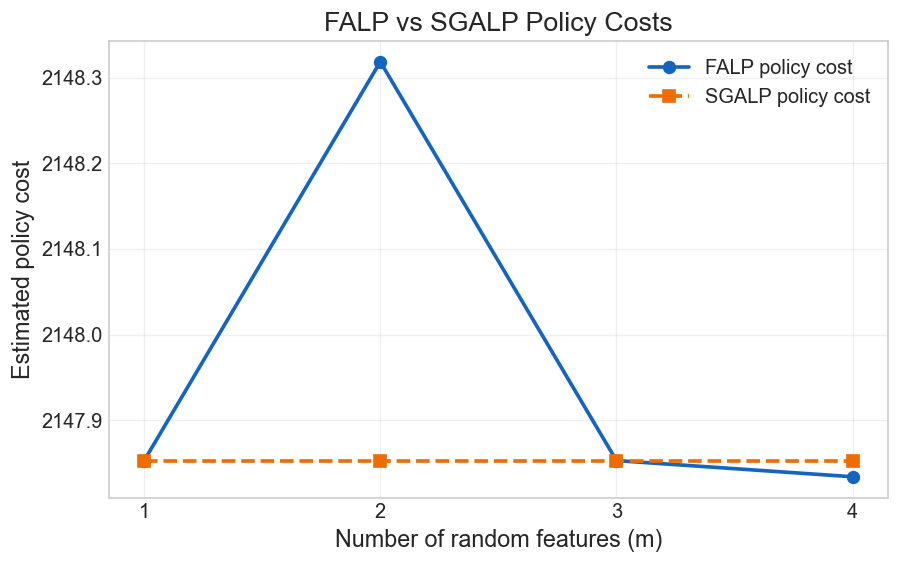

In [10]:
policy_cost_summary = summarize_falp_vs_sgalp_policy_costs(
    comparison_results,
    policy_config=shared_policy_config,
)

for row in policy_cost_summary["rows"]:
    print(
        f"m = {row['m']:>2d} | "
        f"FALP = {row['falp_policy_cost']:8.2f} | "
        f"SGALP = {row['sgalp_policy_cost']:8.2f} | "
        f"difference (FALP - SGALP) = {row['policy_cost_difference']:8.2f}"
    )

plot_falp_vs_sgalp_policy_costs(policy_cost_summary, figsize=(7.6, 4.8))
